In [ ]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    log_loss,
)

import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/atp_matches_2000_2019_clean.csv")

# Features
X = [
    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "height_diff",
    "different_hand",
    "elo_diff",
    "selo_diff",
    "comp_diff",
    "serv_diff",
    "form_diff",
]


# Target
y = "result"

# Empty storage lists
dates = []
predictions = []
actuals = []
probabilities = []
best_params_list = []
cv_monitor = []

# Rolling setup
WINDOW_SIZE = 10000 
STEP = 100

# Base RF model
RF = RandomForestClassifier(
    random_state=1,
    n_jobs=-1
)

# Hyperparameter grid
param_grid = {
    "n_estimators": [150, 200],
    "max_depth": [6, 8],
    "min_samples_leaf": [5, 10],
    "max_features": [3, None],
}

# Rolling window forecast loop
for i in range(WINDOW_SIZE, len(df), STEP):
    train_data = df.iloc[i-WINDOW_SIZE:i]
    test_data = df.iloc[i:i+STEP]

    if len(test_data) == 0:
        break

    X_train = train_data[X]
    y_train = train_data[y]
    X_test = test_data[X]
    y_test = test_data[y]

    tscv = TimeSeriesSplit(n_splits=2)

    search = GridSearchCV(
        estimator=RF,
        param_grid=param_grid,
        cv=tscv,
        n_jobs=-1,
        scoring="neg_log_loss",
        refit=True,
        return_train_score=True
    )

    search.fit(X_train, y_train)

    # CV monitoring
    res = pd.DataFrame(search.cv_results_)
    best_row = res.iloc[search.best_index_]

    cv_monitor.append({
        "Index": i,
        "Date": test_data["tourney_date"].iloc[0],
        "Best_Params": search.best_params_,
        "Mean_Train_Score": float(best_row["mean_train_score"]),
        "Mean_Valid_Score": float(best_row["mean_test_score"]),
    })

    # Store predictions
    best_params_list.append(search.best_params_)
    dates.extend(test_data["tourney_date"].tolist())

    preds = search.predict(X_test)
    probs = search.predict_proba(X_test)[:, 1]

    predictions.extend(preds)
    probabilities.extend(probs)
    actuals.extend(y_test.tolist())

/Users/arttusokka/Documents/AThesis/Predicting-ATP-matches-outcome/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    log_loss,
    brier_score_loss
)

#Confusion matrix
cm = confusion_matrix(actuals, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Accuracy
accuracy = balanced_accuracy_score(actuals, predictions)
print(f"Balanced Accuracy: {accuracy:.3f}")

#Log loss
logloss = log_loss(actuals, probabilities)
print(f"Log Loss: {logloss:.3f}")

#Brier score
brier_score = brier_score_loss(actuals, probabilities)
print(f"Brier Score: {brier_score:.3f}")


NameError: name 'confusion_matrix' is not defined

: 

                Feature  Importance
5              elo_diff    0.270454
6      elo_diff_surface    0.249211
1      rank_points_diff    0.142847
0             rank_diff    0.107598
8         complete_diff    0.066197
9             form_diff    0.055102
2              age_diff    0.044853
7  serve_advantage_diff    0.038691
3           height_diff    0.022555
4        different_hand    0.002491


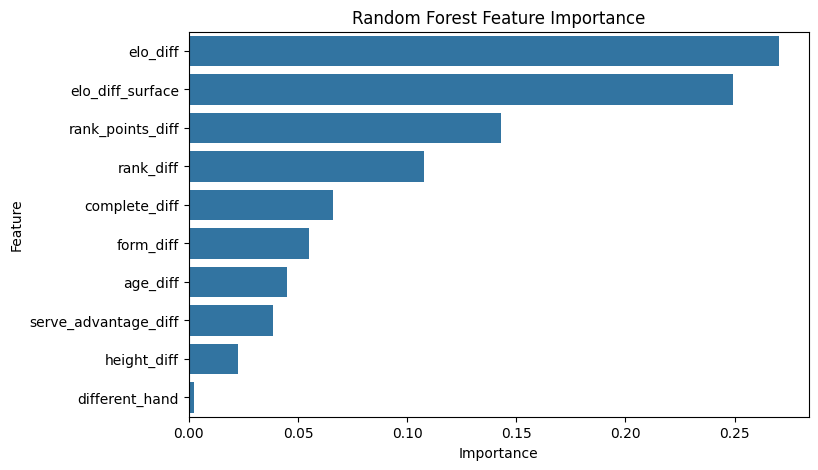

In [ ]:
#RQ2: FEATURE IMPORTANCE
from sklearn.ensemble import RandomForestClassifier

#
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=1,
    n_jobs=-1
)

rf_model.fit(df[X], df[y])

importances = rf_model.feature_importances_

feature_importance_rf = pd.DataFrame({
    "Feature": X,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_rf)

plt.figure(figsize=(8,5))
sns.barplot(
    data=feature_importance_rf,
    x="Importance",
    y="Feature"
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [ ]:
from collections import Counter
import pandas as pd

all_params = {}
total = len(best_params_list)

for d in best_params_list:
    for key, value in d.items():
        if key not in all_params:
            all_params[key] = []
        all_params[key].append(value)

result = []
for param, values in all_params.items():
    counts = Counter(values)
    for val, count in counts.items():
        result.append({
            "Parameter": param,
            "Value": val,
            "Percentage": round(count / total * 100, 1)
        })

df_params = pd.DataFrame(result).sort_values(["Parameter", "Value"])
print(df_params)

          Parameter Value  Percentage
0         max_depth     6        96.3
1         max_depth     8         3.7
3      max_features  log2         5.6
2      max_features  sqrt        94.4
5  min_samples_leaf     5        34.3
4  min_samples_leaf    10        65.7
7      n_estimators   150        27.8
6      n_estimators   200        72.2


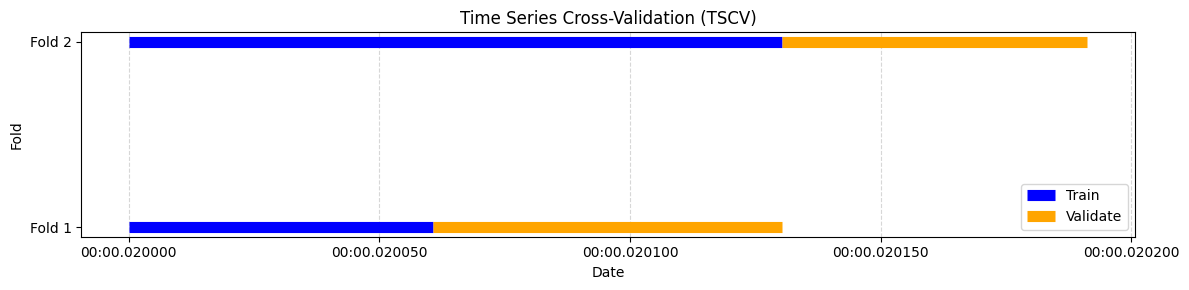